## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate, cross_val_score

# Doğrusal Regresyon (Linear Regression)

🎯 Bu egzersizde, bir NBA oyuncusunun win rating (`win_rating`) performansını, oynadığı dakika (`mp`) gibi maç istatistiklerine göre modelleyeceksiniz.


👉 [NBA.csv](https://d32aokrjazspmn.cloudfront.net/materials/NBA.csv) dataset’ini bu notebook’a bir pandas dataframe olarak yükleyin ve ilk 5 satırını görüntüleyin.

In [6]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\rerso\S16D1-S-data-linear-regression
['.git', '.gitignore', '.ipynb_checkpoints', 'Linear_Regression.ipynb', 'Makefile', 'README.md', 'tests']


In [8]:
import pandas as pd

url = "https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/NBA.csv"

df = pd.read_csv(url)

df.head()

,season,poss,mp,do_ratio,pacing,win_rating
0,1987,4847,2409,-1.546275,-0.599918,1.643091
1,2017,5582,2708,0.996587,0.531888,10.808427
2,2016,4976,2407,0.242598,0.127976,3.054773
3,2021,1178,585,-1.343806,-1.201034,0.230004
4,1988,4534,2056,-1.813990,-0.128997,0.905614


In [10]:
df.shape

(4000, 6)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      4000 non-null   int64  
 1   poss        4000 non-null   int64  
 2   mp          4000 non-null   int64  
 3   do_ratio    4000 non-null   float64
 4   pacing      4000 non-null   float64
 5   win_rating  4000 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 187.6 KB


In [14]:
df.describe().round(2)

,season,poss,mp,do_ratio,pacing,win_rating
count,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,2001.31,2781.61,1379.90,-1.18,0.19,2.04
std,12.52,2021.06,998.75,3.00,0.84,3.47
min,1977.00,1.00,0.00,-32.62,-5.97,-5.43
25%,1991.00,960.75,476.00,-2.80,-0.23,-0.10
50%,2002.00,2577.00,1269.00,-1.15,0.09,0.63
75%,2012.00,4340.75,2155.00,0.53,0.51,3.23
max,2021.00,9271.00,4270.00,28.37,23.73,26.67


In [16]:
df.corr(numeric_only=True).round(2)

,season,poss,mp,do_ratio,pacing,win_rating
season,1.00,-0.15,-0.12,0.01,-0.08,-0.04
poss,-0.15,1.00,1.00,0.59,-0.30,0.74
mp,-0.12,1.00,1.00,0.59,-0.30,0.75
do_ratio,0.01,0.59,0.59,1.00,-0.17,0.67
pacing,-0.08,-0.30,-0.30,-0.17,1.00,-0.20
win_rating,-0.04,0.74,0.75,0.67,-0.20,1.00


Korelasyon analizi sonucunda win_rating ile en güçlü pozitif ilişkinin mp (0.75) ve poss (0.74) değişkenlerinde olduğu görülmüştür. Bu sonuç, daha fazla süre alan ve daha fazla possession içinde yer alan oyuncuların takımlarına daha fazla katkı sağladığını göstermektedir. do_ratio değişkeni de win_rating ile güçlü pozitif ilişki göstermektedir (0.67). Buna karşılık pacing (-0.20) ve season (-0.04) değişkenlerinin win_rating ile ilişkisi zayıftır.

# ℹ️ Dataset’in detaylı açıklamasını challenge README dosyasında bulabilirsiniz. Challenge boyunca buna mutlaka referans verin.


## 1. Özellik Setini ve Hedefi Tanımlayın (Define Feature Set and Target)

🎯 İlk hedef, oyuncuların akranlarına kıyasla genel performans puanı olan *Wins Above Replacement* (`win_rating`) değerini, oynadıkları dakika sayısına (`mp`) göre modellemektir.

👉 Bu iki değişkeni `X` ve `y` olarak atayın. `X`’in feature(lar), `y`’nin ise target olduğunu unutmayın.

In [19]:
X = df[['mp']]

y = df['win_rating']

In [21]:
print(X.shape)
print(y.shape)

(4000, 1)
(4000,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
print(X_train.shape)
print(X_test.shape)

(3200, 1)
(800, 1)


In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [29]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Intercept: -1.5311975122641077
Coefficient: [0.00258271]


## Linear Regression Interpretation

The coefficient of the model is 0.00258, indicating that each additional minute played is associated with an average increase of approximately 0.00258 in win_rating. The positive coefficient confirms a positive relationship between playing time and player contribution.

The intercept is -1.53, which represents the predicted win_rating when the number of minutes played is zero.

The regression plot shows an upward trend, suggesting that players who play more minutes tend to have higher win ratings. However, the data points are not perfectly aligned around the regression line, indicating that win_rating is also influenced by other factors beyond playing time.

👉 Bir [scatter plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) kullanarak rating ile oynanan dakika sayısı arasındaki ilişkiyi görselleştirin.

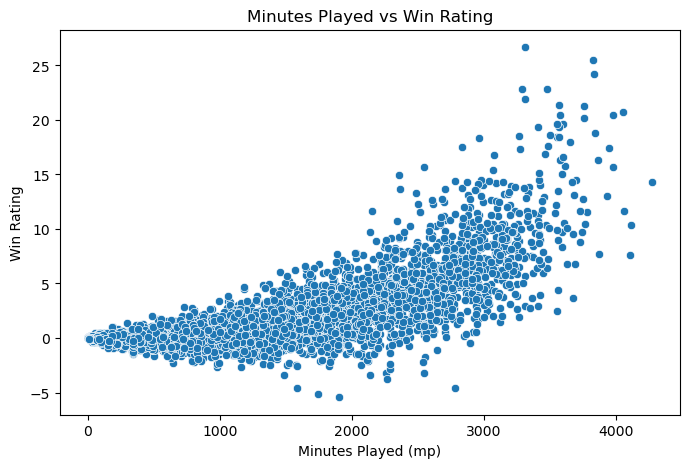

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="mp",
    y="win_rating"
)

plt.title("Minutes Played vs Win Rating")
plt.xlabel("Minutes Played (mp)")
plt.ylabel("Win Rating")

plt.show()

ℹ️ Scatter plot, aralarında bir ilişki olduğunu düşündürmeli. Ancak bu ilişki tamamen doğrusal mı? 🤔 Göreceğiz!

## 2. Çapraz Doğrulama (Cross-Validation)

👉 Sklearn’in [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html) fonksiyonunu kullanarak, oyuncu performans rating’ini oynanan dakika sayısına göre tahmin eden bir [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) modeli üzerinde 5-fold cross-validation çalıştırın. Cross-validation’ın ham çıktısını `cv_results` adlı yeni bir değişkende saklayın.

In [34]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression

model = LinearRegression()

cv_results = cross_validate(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

cv_results

{'fit_time': array([0.00828123, 0.0082972 , 0.00368381, 0.00781751, 0.00571465]),
 'score_time': array([0.        , 0.00579858, 0.00099134, 0.00698519, 0.00258374]),
 'test_score': array([0.5555057 , 0.53447908, 0.53790391, 0.57658459, 0.57917762])}

❓ Cross-validation sonuçları içindeki en düşük skor nedir?  
Cevabınızı hesaplayın ve değeri `min_score` adlı yeni bir değişkende saklayın.

In [36]:
min_score = cv_results["test_score"].min()

min_score

0.53447908222725

❓ Cross-validation sonuçları içindeki en yüksek skor nedir?  
Cevabınızı hesaplayın ve değeri `max_score` adlı yeni bir değişkende saklayın.

In [38]:
max_score = cv_results["test_score"].max()

max_score

0.5791776193355005

❓ Cross-validation sonuçlarının ortalama skoru nedir?  
Cevabınızı hesaplayın ve değeri `mean_score` adlı yeni bir değişkende saklayın.

In [40]:
mean_score = cv_results["test_score"].mean()

mean_score

0.5567301800068911

## Cross Validation Results

The 5-fold cross-validation results show a minimum R² score of 0.5345, a maximum R² score of 0.5792, and an average R² score of 0.5567.

This means that approximately 55.7% of the variation in win_rating can be explained by the number of minutes played. The relatively small difference between the minimum and maximum scores indicates that the model performs consistently across different subsets of the data.

Overall, minutes played is an important predictor of win_rating, although additional variables would be needed to improve predictive performance.

R² (R-Squared) measures how much of the variation in win_rating can be explained by the model. A higher R² score indicates that the model explains the data better. In this project, R² shows how well the number of minutes played predicts player win_rating.

ℹ️ Cross-validation çalıştırırken, model performansının en sağlam ve en temsil edici değerlendirmesi olarak her zaman ortalama skora bakarız.

### ☑️ Kodunu Test Et

In [44]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'cv_results',
    cv_result = cv_results,
    mean_score = mean_score
)

result.write()
print(result.check())


============================= test session starts =============================
platform win32 -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0 -- C:\Users\rerso\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\rerso\S16D1-S-data-linear-regression\tests
plugins: anyio-4.2.0, dash-4.2.0
collecting ... collected 2 items

test_cv_results.py::TestCvResults::test_cv_mean PASSED                   [ 50%]
test_cv_results.py::TestCvResults::test_cv_results PASSED                [100%]

============================== 2 passed in 0.38s ==============================


💯 You can commit your code:

git add tests/cv_results.pickle

git commit -m 'Completed cv_results step'

git push origin master



🤔 **Şimdi K-fold sayısının `K` (yani `cross_validate()` içindeki `cv` parametresi) etkisini inceleyelim**

👉 `K` değeri 2’den 20’ye çıkarken **<u>toplam</u> hesaplama süresinin (fit + score)** ve **<u>ortalama</u> skorun** nasıl değiştiğini plot edin.

<details>
  <summary markdown='span'><strong>İpucu</strong></summary>

  1. `K` değerlerini, hesaplama sürelerini ve cv ortalama skorlarını saklamak için 3 liste oluşturun.
  1. 2’den 20’ye kadar `K` değerleri üzerinde döngü kurun ve her seferinde:
     1. Cross-validation çalıştırın.
     1. `fit_time` ve `score_time` toplamını, toplam süreler listenize ekleyin.
     1. Ortalama `test_score` değerini, cv ortalama skorları listenize ekleyin.
  1. İki adet plot oluşturun:
     1. `K`’ye karşı toplam süre.
     1. `K`’ye karşı ortalama skor.
</details>


In [46]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression
import numpy as np

k_values = range(2, 21)

mean_scores = []
times = []

for k in k_values:
    
    cv_results = cross_validate(
        LinearRegression(),
        X,
        y,
        cv=k,
        scoring="r2"
    )

    mean_scores.append(
        cv_results["test_score"].mean()
    )

    total_time = (
        cv_results["fit_time"].sum()
        + cv_results["score_time"].sum()
    )

    times.append(total_time)

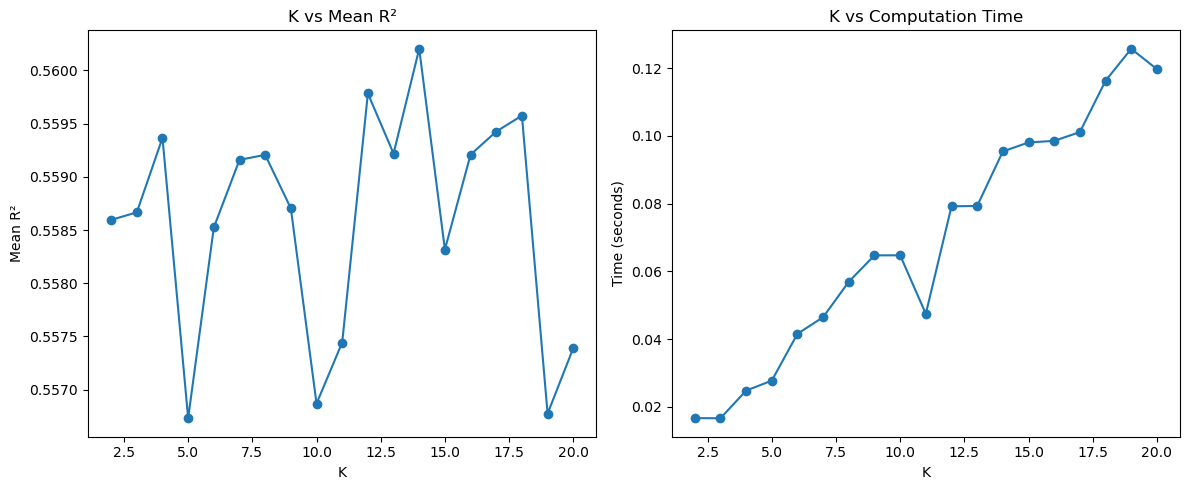

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(k_values, mean_scores, marker="o")
plt.title("K vs Mean R²")
plt.xlabel("K")
plt.ylabel("Mean R²")

plt.subplot(1,2,2)
plt.plot(k_values, times, marker="o")
plt.title("K vs Computation Time")
plt.xlabel("K")
plt.ylabel("Time (seconds)")

plt.tight_layout()
plt.show()

## Effect of K in Cross Validation

As the value of K increases from 2 to 20, the mean R² score remains relatively stable around 0.56. This indicates that the model produces consistent results regardless of the number of folds used.

On the other hand, computation time increases steadily as K increases because the model must be trained and evaluated more times. Therefore, larger K values provide little improvement in model evaluation while requiring more computation time.

This supports the common practice of using K=5 or K=10 as a good balance between reliability and efficiency.

Bir yönetici gözüyle yorumlarsak:

"Oyuncunun oynadığı dakika sayısı, win_rating'in yaklaşık %56'sını açıklıyor. Sonuçlar farklı test senaryolarında da benzer çıktığı için model güvenilir görünüyor. Ancak win_rating'in tamamını açıklayamadığımız için poss, do_ratio ve pacing gibi ek değişkenleri modele eklemek performansı artırabilir."

ℹ️ $R^2$ skorunun sabit kaldığını görmelisiniz; bu, modelin hem daha küçük hem de daha büyük test setlerinde benzer performans gösterdiğinin iyi bir işaretidir. Buna karşılık, hesaplama süresi artmaya devam eder. Bu nedenle, pratik bir kural olarak genellikle K = 10’un üzerine çıkmayız.

## 3. Modeli eğit (Train the Model)

Cross-validation, veri seti üzerinde varsayımsal bir modeli değerlendirmek için kullanılır. Seçtiğiniz fold sayısı kadar modeli birden fazla kez eğitir; her seferinde verinin farklı bir alt kümesi üzerinde eğitilir ve kalan veriyle skor hesaplanır. Bu süreç bize, modelin ne kadar iyi performans gösterebileceğini gösteren cross-validated bir skor verir.

Ancak modeli gerçek anlamda tahmin yapmak için kullanmak istediğinizde, mümkün olduğunca fazla veriyle eğitmeyi tercih edersiniz. Yani verinin bir kısmını ayırmadan.

👉 Modeli, tam `X` ve `y` üzerinde eğitin (model skorunu zaten doğruladık, şimdi tahmin için kullanacağız). Eğitilmiş modeli `model` adlı değişkende saklayın.

In [54]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

model

LinearRegression()

❓ Eğitilmiş modelinizin eğimi (slope) ya da katsayısı (coefficient) nedir?  
Bu değere modelin attribute’ları üzerinden erişebilirsiniz. Eğimi `slope` adlı bir değişkende saklayın.

In [56]:
slope = model.coef_[0]

slope

0.002602579938640194

❓ Eğitilmiş modelinizin intercept (sabit terim) değeri nedir?  
Bu değere modelin attribute’ları üzerinden erişebilirsiniz. Intercept değerini `intercept` adlı bir değişkende saklayın.

In [58]:
intercept = model.intercept_

intercept

-1.5463749371639457

🤔 Devam etmeden önce bu katsayıları nasıl yorumlayacağınızı anladığınızdan emin olun.

### ☑️ Kodunu Test Et

In [60]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'trained_model',
    slope = slope,
    intercept = intercept
)

result.write()
print(result.check())


============================= test session starts =============================
platform win32 -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0 -- C:\Users\rerso\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\rerso\S16D1-S-data-linear-regression\tests
plugins: anyio-4.2.0, dash-4.2.0
collecting ... collected 2 items

test_trained_model.py::TestTrainedModel::test_intercept PASSED           [ 50%]
test_trained_model.py::TestTrainedModel::test_slope PASSED               [100%]

============================== 2 passed in 0.27s ==============================


💯 You can commit your code:

git add tests/trained_model.pickle

git commit -m 'Completed trained_model step'

git push origin master



## 4. Tahmin (Predict)

👉 Eğitilmiş modelinizi kullanarak toplamda 1000 dakika oynamış bir oyuncunun performans rating’ini tahmin edin.  
Tahmin edilen değeri `prediction` adlı bir değişkende saklayın.

In [64]:
new_datapoint = pd.DataFrame.from_dict(
    {"mp": [1000]}
)

prediction = model.predict(new_datapoint)

prediction

array([1.056205])

A player who has played 1000 minutes is predicted to have a win_rating of approximately 1.05. This suggests a positive contribution to the team compared with a replacement-level player, although the contribution is below the dataset average win_rating of 2.04.

## Prediction

Using the trained Linear Regression model, a player who has played 1000 minutes is predicted to have a win_rating of approximately 1.05.

This prediction is based solely on playing time and does not account for other performance-related variables.

### ☑️ Kodunu Test Et

In [67]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'prediction',
    prediction = prediction
)

result.write()
print(result.check())


============================= test session starts =============================
platform win32 -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0 -- C:\Users\rerso\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\rerso\S16D1-S-data-linear-regression\tests
plugins: anyio-4.2.0, dash-4.2.0
collecting ... collected 1 item

test_prediction.py::TestPrediction::test_prediction PASSED               [100%]

============================== warnings summary ===============================
test_prediction.py::TestPrediction::test_prediction
  C:\Users\rerso\S16D1-S-data-linear-regression\tests\test_prediction.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
    self.assertGreater(float(self.result.prediction), 1)

test_prediction.py::TestPrediction::test_prediction
  C:\Users\rerso\S16D1-S-data-linear-regression\t

## 5.  Daha Fazla Özellik ile Modeli İyileştirme (Improving the Model with More Features)

NBA fantasy league’i seven bir arkadaşınız size bazı içgörülerle geliyor 🏀

Bir oyuncunun *Wins Above Replacement* rating’ini değerlendirirken, genellikle topa sahip olma sayısına (`poss`), savunma/hücum oranına (`do_ratio`) ve `pacing` değerine de baktıklarını söylüyor.

❓ Aşağıdaki hücreyi çalıştırarak bu yeni feature’lar ile `win_rating` arasındaki korelasyonu görselleştirin.  
Yukarıdaki feature’lardan **hangisini** modelinize eklemeyi düşünürdünüz?

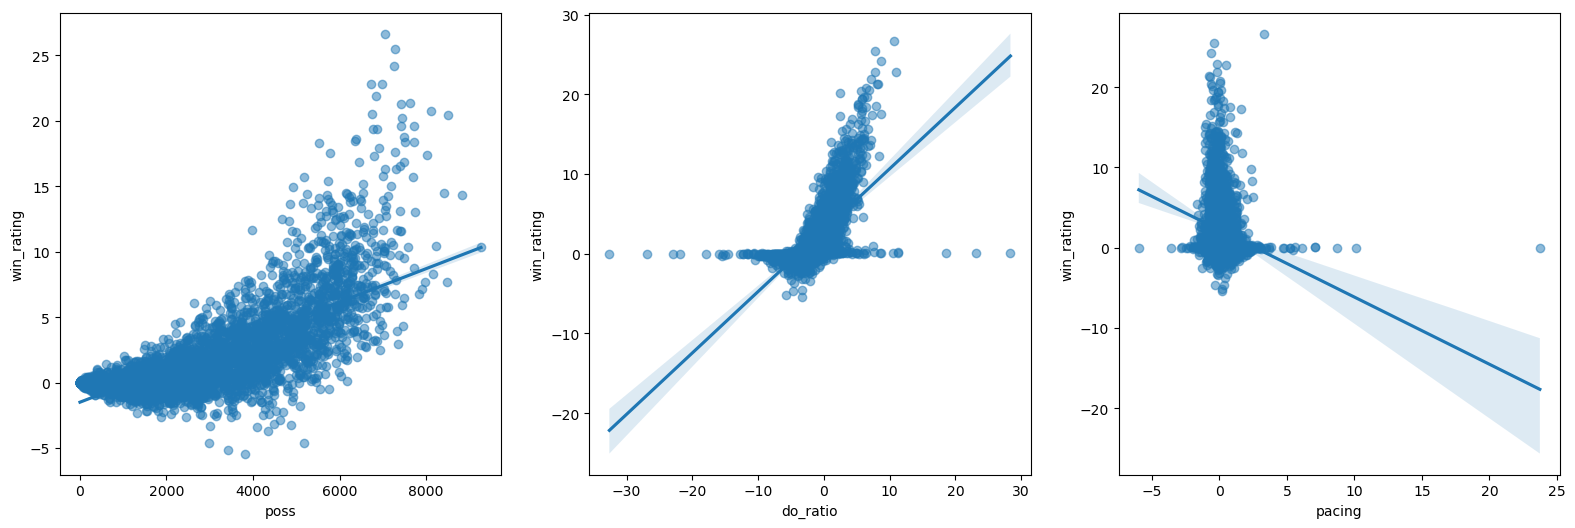

In [69]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 6))

plt.subplots_adjust(left=0.5, right=2)

sns.regplot(data=df, y='win_rating', x='poss', ax=axes[0], scatter_kws={'alpha':0.5})
sns.regplot(data=df, y='win_rating', x='do_ratio', ax=axes[1], scatter_kws={'alpha':0.5})
sns.regplot(data=df, y='win_rating', x='pacing', ax=axes[2], scatter_kws={'alpha':0.5})

plt.show()

The pacing variable has a weak negative correlation (-0.20) with win_rating. This suggests that game tempo alone is not a strong predictor of player contribution compared to variables such as mp, poss, or do_ratio.

<details>
  <summary markdown='span'><strong>Cevap</strong></summary>

  Feature’ları manuel olarak seçecek olsaydınız, hedef değişken olan `win_rating` ile en yüksek korelasyona sahip olanlarla başlardınız.

  Regresyon plot’larına baktığımızda, geriye `poss` ve `do_ratio` kalıyor. Sayısal değerleri görmek isterseniz `df.corr()[['win_rating']]` çıktısına bakabilirsiniz.

  Peki neden `poss` değil? Sonuçta `win_rating` ile olan korelasyonu `do_ratio`’dan daha yüksek.

  Bir de şuna bakın: `sns.scatterplot(data=df, x='mp', y='poss');`. Nedenini görebiliyor musunuz?

  <details>
  <summary><strong>Cevap</strong></summary>

  Görünen o ki, ilk feature’ımız olan `mp` ile `poss` neredeyse mükemmele yakın şekilde korelasyonlu. Bu yüzden `poss`, modele çok az ek değer katacaktır.

Sadece korelasyona bakarsak:

poss     0.74
do_ratio 0.67
pacing  -0.20

en mantıklı seçim:

poss

olur.

corr(mp, poss) = 1.00

bulmuştuk.

Bu çok önemli.

Çünkü:

mp ve poss neredeyse aynı bilgiyi taşıyor.

Yani modele:

X = ['mp', 'poss']

eklersen performans çok fazla artmayabilir.

Buna istatistikte multicollinearity denir.

Bu yüzden eğitmen muhtemelen şunu fark etmeni istiyor:

Daha mantıklı seçim
mp + do_ratio

çifti.


corr(mp, poss) = 1.00

bulmuştuk.

Bu çok önemli.

Çünkü:

mp ve poss neredeyse aynı bilgiyi taşıyor.

Yani modele:

X = ['mp', 'poss']

eklersen performans çok fazla artmayabilir.

Buna istatistikte multicollinearity denir.

Bu yüzden eğitmen muhtemelen şunu fark etmeni istiyor:

Daha mantıklı seçim
mp + do_ratio

çifti.

Şimdi, iki feature kullanan modelin (seçtiğiniz yeni feature ve `mp`) bir oyuncunun rating’ini tahmin etmede ilk modelimizden daha iyi olup olmadığına bakalım.

👉 İki sütunlu bir DataFrame olacak şekilde yeni bir feature set’i oluşturun.

In [78]:
X_2 = df[["mp", "do_ratio"]]

X_2.head()

,mp,do_ratio
0,2409,-1.546275
1,2708,0.996587
2,2407,0.242598
3,585,-1.343806
4,2056,-1.813990


👉 Şimdi yeni bir linear regression modeli için cross-validation çalıştırın ve **ortalama** skoru `mean_2_feat_score` değişkenine kaydedin.

> Not: Eğer sadece cross-validation skoruyla ilgileniyorsanız (hesaplama süreleriyle değil), sklearn’in [`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) fonksiyonunu kullanabilirsiniz.

In [80]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

scores = cross_val_score(
    LinearRegression(),
    X_2,
    y,
    cv=5,
    scoring="r2"
)

mean_2_feat_score = scores.mean()

mean_2_feat_score

0.6317728310765246

### ☑️ Kodunu Test Et

In [82]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'improved_score',
    improved_score = mean_2_feat_score
)

result.write()
print(result.check())


============================= test session starts =============================
platform win32 -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0 -- C:\Users\rerso\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\rerso\S16D1-S-data-linear-regression\tests
plugins: anyio-4.2.0, dash-4.2.0
collecting ... collected 1 item

test_improved_score.py::TestImprovedScore::test_improved_score PASSED    [100%]

============================== 1 passed in 0.28s ==============================


💯 You can commit your code:

git add tests/improved_score.pickle

git commit -m 'Completed improved_score step'

git push origin master



## Feature Engineering Results

The initial model using only `mp` achieved an average R² score of 0.5567. After adding `do_ratio` as a second feature, the average R² score increased to 0.6318.

This improvement indicates that `do_ratio` provides additional information about player performance beyond playing time alone. Therefore, the two-feature model explains a larger proportion of the variation in `win_rating` and performs better than the original model.

Sadece oyuncunun kaç dakika oynadığına bakmak yeterli değil. Savunma/hücum dengesi (do_ratio) bilgisini eklediğimizde model daha başarılı hale geliyor. Bu da oyuncu katkısını açıklamak için birden fazla performans göstergesinin kullanılmasının daha doğru olduğunu gösteriyo

$R^2$ değerinizde **yaklaşık %8’lik bir artış** görmelisiniz 👏

Tebrikler, ilk manuel *feature selection* işleminizi gerçekleştirdiniz — bu hafta bunun daha birçok yolunu göreceğiz!

🤔 Peki Linear Regression ile yapabileceğimiz en iyi şey bu mu? Bir sonraki challenge’da bunu daha derinlemesine keşfedelim!

# 🏁